## Datasets
### Basic structures:
- `TSDataset` — TSDataset is the main class to handle your time series data.
- `DataFrameFormat` — Enum for different kinds of `pd.DataFrame` which can be used.
- `HierarchicalStructure` — Represents hierarchical structure of TSDataset.

### Utilities for dataset generation:
- `generate_ar_df` — Create DataFrame with AR process data.
- `generate_const_df` — Create DataFrame with const data.
- `generate_from_patterns_df` — Create DataFrame from patterns.
- `generate_hierarchical_df` — Create DataFrame with hierarchical structure and AR process data.
- `generate_periodic_df` — Create DataFrame with periodic data.

### Utilities for data manipulation:
- `duplicate_data` — Duplicate dataframe for all the segments.
- `set_columns_wide` — Set columns in a left dataframe with values from the right dataframe.
- `infer_alignment` — Inference alignment of a given dataframe.
- `apply_alignment` — Apply given alignment to a dataframe.
- `make_timestamp_df_from_alignment` — Create a dataframe with timestamp according to a given alignment.

### Utilities for working with internal datasets:
- `load_dataset` — Load internal dataset.

## 1. Синтетика
Какие искусственные ряды вообще можно получить, не открывая ни одного файла.

In [108]:
from etna.datasets import TSDataset

In [166]:
PARAMS = {
    "periods":100,
    "start_time":"2026-09-01",
    "scale":67,
    "n_segments":2,
    "freq":"D",
    # https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases
    "add_noise":True,
    "sigma":5,
    "random_seed":42
}

### generate_const_df

In [127]:
from etna.datasets import generate_const_df

In [139]:
df = generate_const_df(**PARAMS)
df

,timestamp,segment,target
0,2026-09-01,segment_0,69.483571
1,2026-09-02,segment_0,66.308678
2,2026-09-03,segment_0,70.238443
3,2026-09-04,segment_0,74.615149
4,2026-09-05,segment_0,65.829233
...,...,...,...
195,2026-12-05,segment_1,68.926587
196,2026-12-06,segment_1,62.580713
197,2026-12-07,segment_1,67.768626
198,2026-12-08,segment_1,67.291044


In [140]:
ts = TSDataset(df, "D")
print(f"df:{type(df)}\nts:{type(ts)}")

df:<class 'pandas.core.frame.DataFrame'>
ts:<class 'etna.datasets.tsdataset.TSDataset'>


In [149]:
ts_p

segment,segment_0,segment_1
feature,target,target
timestamp,,
2026-09-01,53.483571,6.923146
2026-09-02,50.308678,11.896773
2026-09-03,54.238443,12.286427
2026-09-04,58.615149,9.988614
2026-09-05,49.829233,13.193571
...,...,...
2026-12-05,43.682425,15.926587
2026-12-06,52.480601,9.580713


<Axes: >

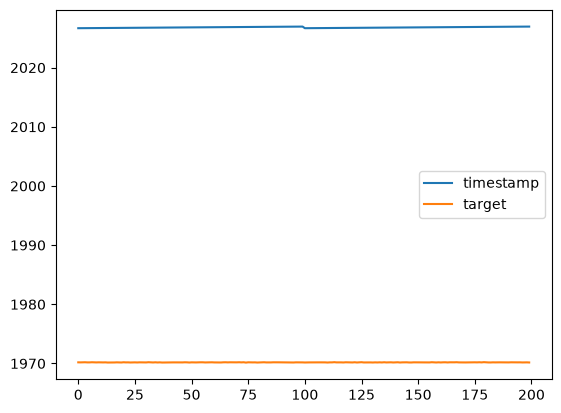

In [142]:
df.plot()

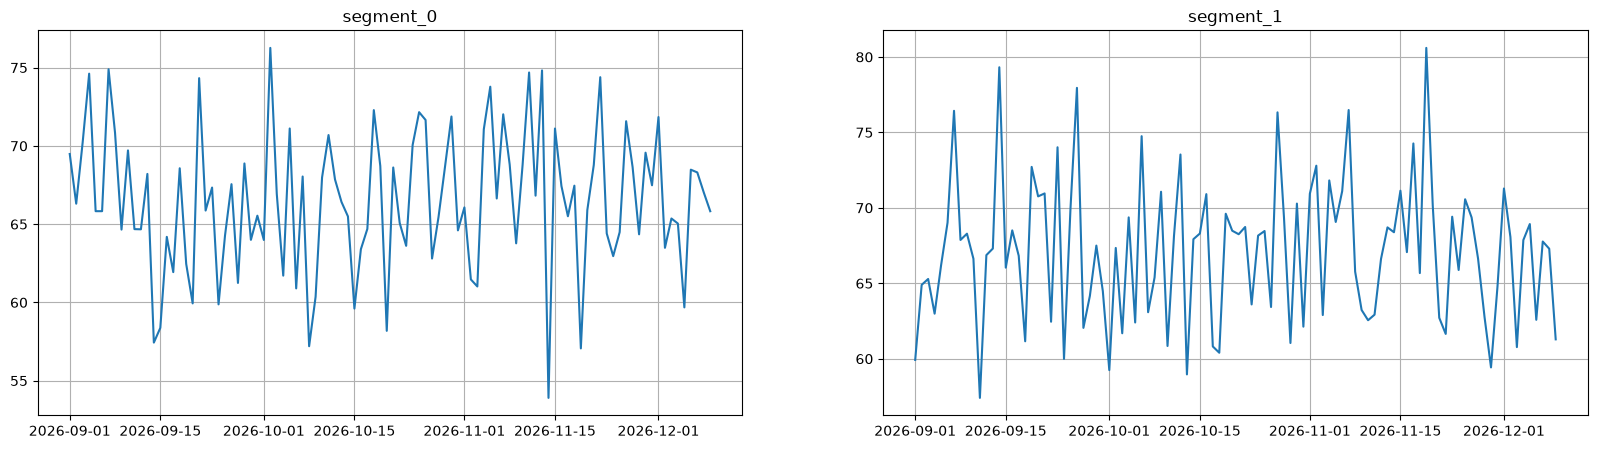

In [143]:
ts.plot()

In [144]:
dir(ts)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_cast_index_to_datetime',
 '_cast_segment_to_str',
 '_cast_target_to_float',
 '_check_endings',
 '_check_known_future',
 '_check_regressors',
 '_current_df_exog_level',
 '_current_df_level',
 '_detect_modified_columns',
 '_df',
 '_df_exog',
 '_expand_index',
 '_find_all_borders',
 '_freq',
 '_gather_common_data',
 '_gather_segments_data',
 '_get_dataframe_level',
 '_get_min_max_valid_timestamp',
 '_hierarchical_structure_from_level_columns',
 '_inverse_transform_target_components',
 '_known_future',
 '_merge_exog',
 '_prediction_intervals_names',
 '_prepare_df',
 '_prepare_df_exog',
 '_ra

### generate_periodic_df

In [131]:
from etna.datasets import generate_periodic_df

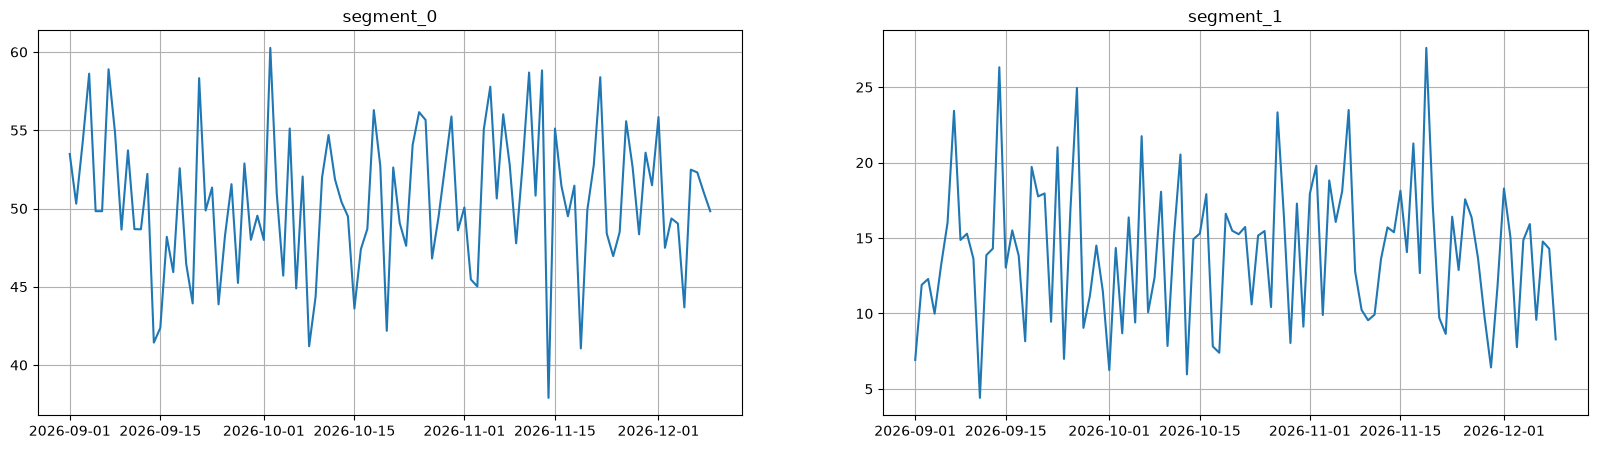

In [156]:
df_p = generate_periodic_df(**PARAMS) # randint(scale)
ts_p = TSDataset(df_p, freq="D")
ts_p.plot()

### generate_ar_df

In [157]:
from etna.datasets import generate_ar_df

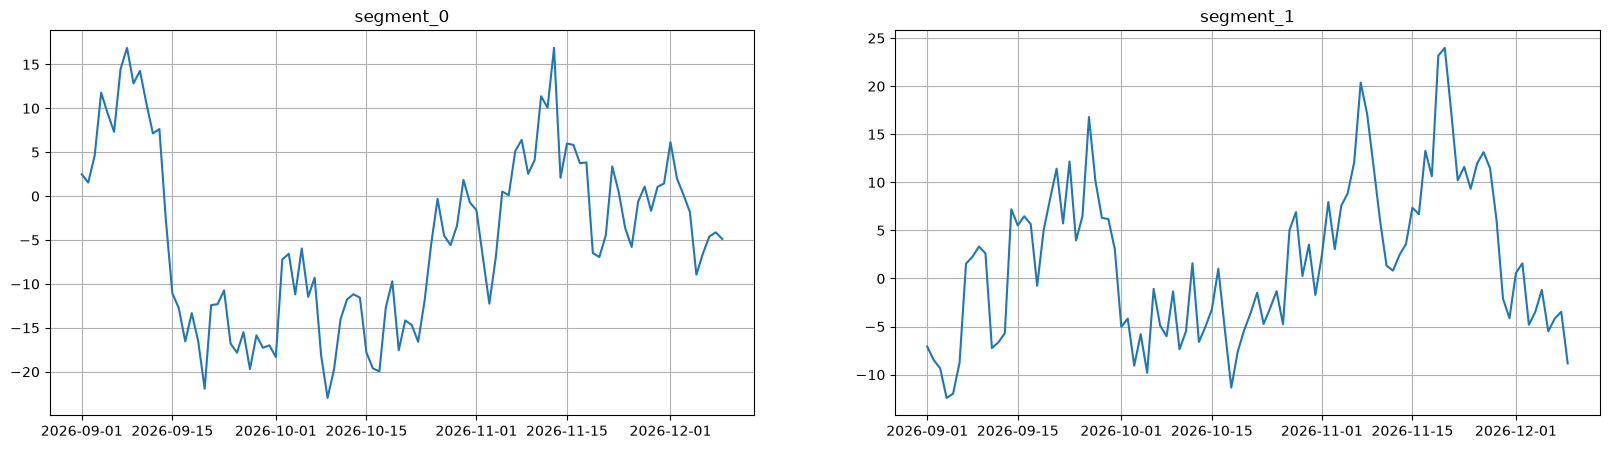

In [184]:
df_ar = generate_ar_df(
    periods=PARAMS["periods"],
    start_time=PARAMS["start_time"],
    n_segments=PARAMS["n_segments"],
    freq=PARAMS["freq"],
    sigma=PARAMS["sigma"],
    random_seed=PARAMS["random_seed"],

    # Генерирует авторегрессионный процесс (AR), где каждое следующее значение зависит от предыдущего
    # X[t] = ar_coef[0] * X[t-1] + шум.

    # Коэффициент близко к 1 значит, что ряд "помнит" себя надолго. Если сейчас высокое значение, следующее тоже, скорее всего, будет высоким. Получается плавный, "гуляющий" ряд, который может подолгу дрейфовать в одну сторону, прежде чем развернуться.

    # Коэффициент близко к 0 значит, что ряд почти не помнит себя. Текущее значение слабо связано с предыдущим, и в основном определяется случайным шумом. Получается дёрганый ряд без выраженной инерции. Скачет туда-сюда без всякой памяти о прошлом. При ar_coef=0 это уже просто чистый белый шум.
    ar_coef=[0.9], #[0.2]
)

ts_ar = TSDataset(df_ar, freq="D")
ts_ar.plot()

### generate_from_patterns_df

In [185]:
from etna.datasets import generate_from_patterns_df

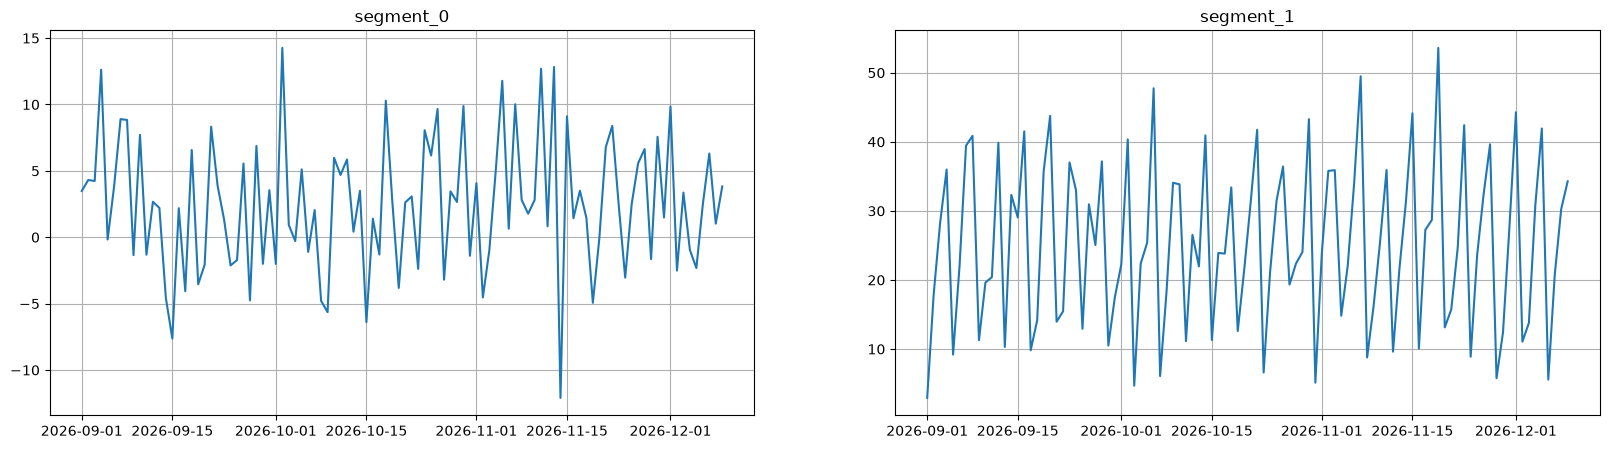

In [199]:
df_p = generate_from_patterns_df(
    periods=PARAMS["periods"],
    start_time=PARAMS["start_time"],
    freq=PARAMS["freq"],
    add_noise=PARAMS["add_noise"],
    sigma=PARAMS["sigma"],
    random_seed=PARAMS["random_seed"],

    # Самый общий генератор с полным контролем над формой цикла, на котором построены и generate_const_df, и generate_periodic_df. Здесь задается точная форма повторяющегося паттерна.

    # Зачем это может быть нужно:
    # - Проверить модель на известном "правильном ответе".
    # - Смоделировать конкретный реальный сценарий ("продажи растут к выходным и падают в будни").
    patterns=[[1.0, 5.0], [10.0, 20.0, 30.0, 40.0]]
)

ts_p = TSDataset(df_p, freq="D")
ts_p.plot()

### generate_hierarchical_df

In [200]:
from etna.datasets import generate_hierarchical_df

In [217]:
df_h = generate_hierarchical_df(
    periods=PARAMS["periods"],
    start_time=PARAMS["start_time"],
    freq=PARAMS["freq"],
    sigma=PARAMS["sigma"],
    random_seed=PARAMS["random_seed"],


    n_segments=[2, 4],
    ar_coef=[0.9],
)

df_h

,timestamp,target,level_1,level_0
0,2026-09-01,2.483571,l1s0,l0s0
1,2026-09-02,1.543892,l1s0,l0s0
2,2026-09-03,4.627946,l1s0,l0s0
3,2026-09-04,11.780300,l1s0,l0s0
4,2026-09-05,9.431503,l1s0,l0s0
...,...,...,...,...
395,2026-12-05,7.913844,l1s3,l0s1
396,2026-12-06,-1.443213,l1s3,l0s1
397,2026-12-07,5.470470,l1s3,l0s1
398,2026-12-08,4.350724,l1s3,l0s1


In [219]:
df_h.groupby(["level_0", "level_1"]).agg("count")

timestamp  target
level_0 level_1                   
l0s0    l1s0           100     100
        l1s1           100     100
l0s1    l1s2           100     100
        l1s3           100     100